<a href="https://colab.research.google.com/github/sasurasa/Lin/blob/main/Lin120726SS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = "/content/apri.xlsx"
sheet_name = "cleanup (2)"
df = pd.read_excel(file_path, sheet_name=sheet_name)

In [ ]:
apri_columns = [
    "preapri",
    "immapri",
    "d7apri",
    "m1apri",
    "m4apri",
    "m5apri",
    "m6apri",
    "y2apri",
    "y5apri"
]

In [ ]:
time_labels = [
    "Pre-HPE",
    "Immediate\npost-op",
    "Day 7",
    "Month 1",
    "Month 4",
    "Month 5",
    "Month 6",
    "Year 2",
    "Year 5"
]

In [ ]:
#Data preparation
for column in apri_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
df[apri_columns] = df[apri_columns].mask(df[apri_columns] < 0)

In [ ]:
summary = pd.DataFrame({
    "column": apri_columns,
    "time": time_labels,
    "n": [df[column].count() for column in apri_columns],
    "mean": [df[column].mean() for column in apri_columns],
    "sd": [df[column].std(ddof=1) for column in apri_columns],
    "median": [df[column].median() for column in apri_columns],
    "q1": [df[column].quantile(0.25) for column in apri_columns],
    "q3": [df[column].quantile(0.75) for column in apri_columns]
})

summary["lower_sd"] = np.maximum(summary["mean"] - summary["sd"], 0)
summary["upper_sd"] = summary["mean"] + summary["sd"]

In [ ]:
summary

,column,time,n,mean,sd,median,q1,q3,lower_sd,upper_sd
0,preapri,Pre-HPE,105,1.899193,2.041864,1.197339,0.719697,2.128099,0.000000,3.941057
1,immapri,Immediate\npost-op,101,6.801412,7.517439,4.063107,2.309741,8.106996,0.000000,14.318850
2,d7apri,Day 7,100,0.905487,0.829641,0.673645,0.460804,0.946555,0.075846,1.735127
3,m1apri,Month 1,90,1.389747,1.323258,0.993731,0.506535,1.876236,0.066489,2.713005
4,m4apri,Month 4,85,1.689359,1.909942,1.079812,0.558659,2.095588,0.000000,3.599302
5,m5apri,Month 5,84,1.431203,1.330116,0.986207,0.544217,1.682678,0.101087,2.761318
6,m6apri,Month 6,84,1.448142,1.297012,1.014033,0.531669,1.934705,0.151130,2.745155
7,y2apri,Year 2,78,1.703702,2.051822,0.996324,0.489096,2.167770,0.000000,3.755524
8,y5apri,Year 5,59,0.853390,0.604100,0.660000,0.410000,1.085000,0.249290,1.457490


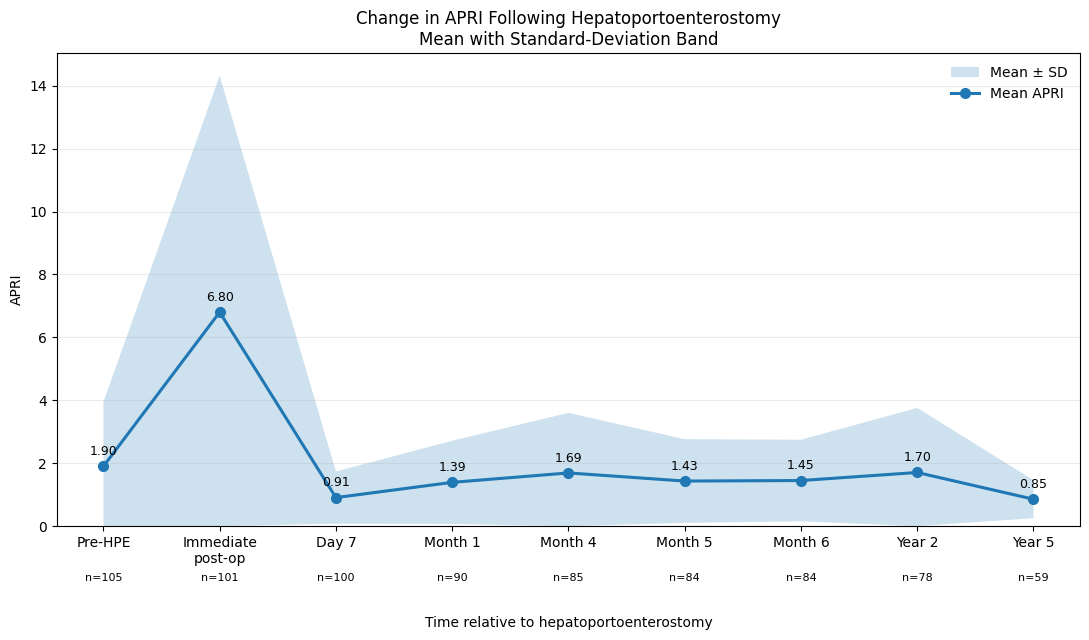

In [ ]:
x = np.arange(len(summary))

fig, ax = plt.subplots(figsize=(11, 6.5))

# Standard-deviation ribbon
ax.fill_between(
    x,
    summary["lower_sd"].to_numpy(),
    summary["upper_sd"].to_numpy(),
    alpha=0.22,
    label="Mean ± SD"
)

# Mean line
ax.plot(
    x,
    summary["mean"],
    marker="o",
    linewidth=2.2,
    markersize=7,
    label="Mean APRI"
)

# Add mean values above each point
for i, row in summary.iterrows():
    ax.annotate(
        f'{row["mean"]:.2f}',
        xy=(i, row["mean"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# Add the available sample size below the x-axis labels
for i, row in summary.iterrows():
    ax.annotate(
        f'n={int(row["n"])}',
        xy=(i, 0),
        xytext=(0, -34),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(summary["time"])

ax.set_xlabel("Time relative to hepatoportoenterostomy", labelpad = 36)
ax.set_ylabel("APRI")
ax.set_title(
    "Change in APRI Following Hepatoportoenterostomy\n"
    "Mean with Standard-Deviation Band"
)

ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

# Additional lower margin for sample sizes
plt.subplots_adjust(bottom=0.22)
plt.tight_layout()

plt.savefig(
    "APRI_mean_SD_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "APRI_mean_SD_over_time.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
df["twoyrjclear"] = pd.to_numeric(
    df["twoyrjclear"],
    errors="coerce"
)

plot_df = df[df["twoyrjclear"].isin([0, 1])].copy()

group_labels = {
    0: "No jaundice clearance",
    1: "Jaundice clearance"
}

In [ ]:
#Calculate group-specific summary statistics

summary_rows = []

for group_value, group_name in group_labels.items():

    group_df = plot_df[
        plot_df["twoyrjclear"] == group_value
    ]

    for column, time_label in zip(apri_columns, time_labels):

        values = group_df[column].dropna()

        summary_rows.append({
            "group_value": group_value,
            "group": group_name,
            "column": column,
            "time": time_label,
            "n": len(values),
            "mean": values.mean(),
            "sd": values.std(ddof=1)
        })

summary = pd.DataFrame(summary_rows)

summary["lower_sd"] = np.maximum(
    summary["mean"] - summary["sd"],
    0
)

summary["upper_sd"] = (
    summary["mean"] + summary["sd"]
)
print(
    summary[
        ["group", "time", "n", "mean", "sd"]
    ].round(3)
)

                    group                time   n    mean      sd
0   No jaundice clearance             Pre-HPE  40   2.841   2.750
1   No jaundice clearance  Immediate\npost-op  38  10.145  10.197
2   No jaundice clearance               Day 7  38   1.196   1.128
3   No jaundice clearance             Month 1  30   2.066   1.773
4   No jaundice clearance             Month 4  27   2.383   1.600
5   No jaundice clearance             Month 5  25   2.259   1.684
6   No jaundice clearance             Month 6  23   2.381   1.447
7   No jaundice clearance              Year 2  16   2.338   1.612
8   No jaundice clearance              Year 5  11   0.886   0.662
9      Jaundice clearance             Pre-HPE  64   1.307   1.131
10     Jaundice clearance  Immediate\npost-op  62   4.500   3.637
11     Jaundice clearance               Day 7  61   0.723   0.513
12     Jaundice clearance             Month 1  60   1.052   0.865
13     Jaundice clearance             Month 4  58   1.366   1.968
14     Jau

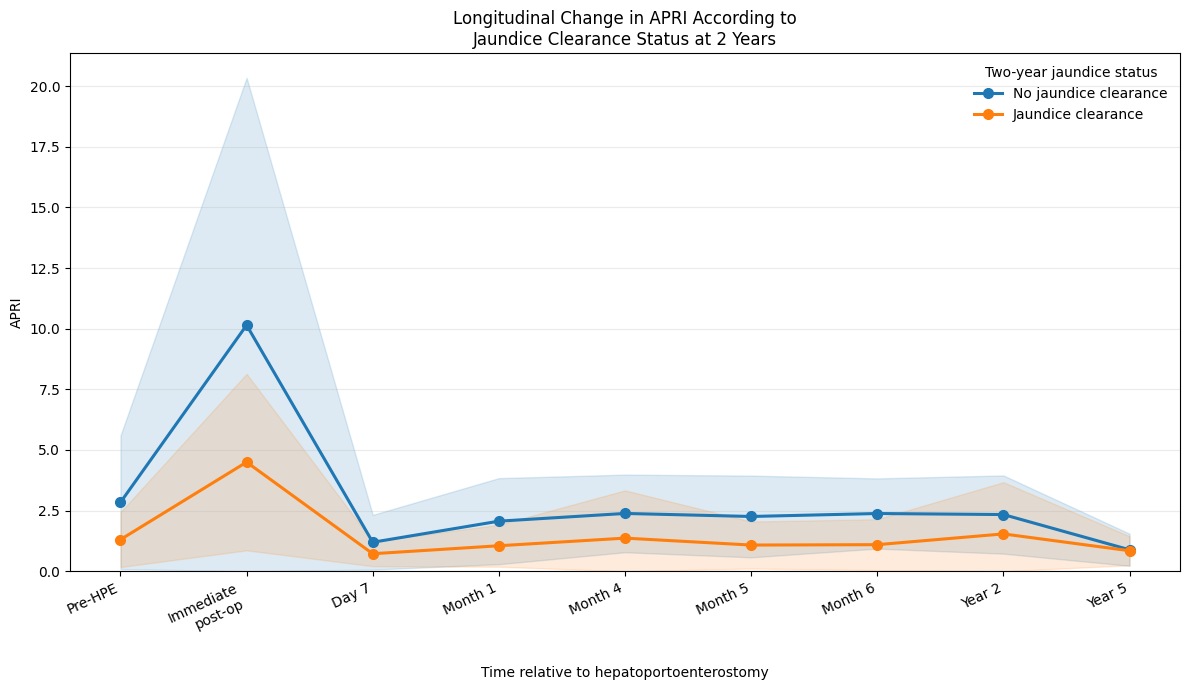

In [ ]:
x = np.arange(len(time_labels))

fig, ax = plt.subplots(figsize=(12, 7))

for group_value, group_name in group_labels.items():

    group_summary = (
        summary[
            summary["group_value"] == group_value
        ]
        .set_index("column")
        .loc[apri_columns]
        .reset_index()
    )

    # Mean trajectory
    line = ax.plot(
        x,
        group_summary["mean"],
        marker="o",
        linewidth=2.2,
        markersize=7,
        label=group_name
    )[0]

    # SD ribbon using the same color as the line
    ax.fill_between(
        x,
        group_summary["lower_sd"].to_numpy(),
        group_summary["upper_sd"].to_numpy(),
        alpha=0.15,
        color=line.get_color()
    )

# ------------------------------------------------------------
# 5. Axis labels and formatting
# ------------------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(
    time_labels,
    rotation=25,
    ha="right",
    linespacing=1.3
)

ax.set_xlabel(
    "Time relative to hepatoportoenterostomy",
    labelpad=18
)

ax.set_ylabel("APRI")

ax.set_title(
    "Longitudinal Change in APRI According to\n"
    "Jaundice Clearance Status at 2 Years"
)

ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.25)

ax.legend(
    title="Two-year jaundice status",
    frameon=False
)

fig.subplots_adjust(bottom=0.25)
plt.tight_layout()

plt.savefig(
    "APRI_by_2year_jaundice_clearance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "APRI_by_2year_jaundice_clearance.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
#data_preprocessing
# Keep cases with known jaundice-clearance status

df = df[df["twoyrjclear"].isin([0, 1])].copy()

df["Jaundice clearance"] = df["twoyrjclear"].map({
    0: "No clearance",
    1: "Clearance"
})

In [ ]:
long_df = df.melt(
    id_vars=["Jaundice clearance"],
    value_vars=apri_columns,
    var_name="time_variable",
    value_name="APRI"
)

long_df["Time"] = long_df["time_variable"].map(time_mapping)

# Preserve chronological order
time_order = [time_mapping[column] for column in apri_columns]

long_df["Time"] = pd.Categorical(
    long_df["Time"],
    categories=time_order,
    ordered=True
)
long_df = long_df.dropna(
    subset=["APRI", "Jaundice clearance"]
)

/tmp/ipykernel_2538/3975502953.py:5: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


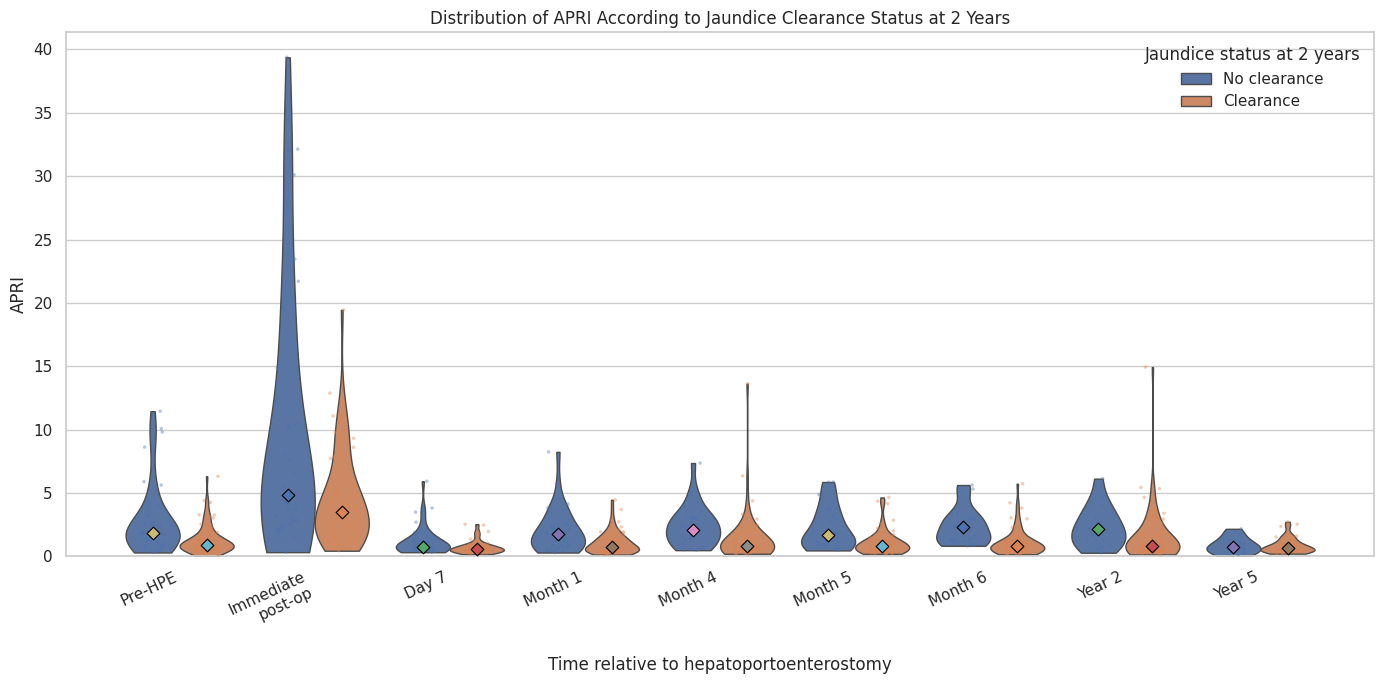

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14, 7))

sns.violinplot(
    data=long_df,
    x="Time",
    y="APRI",
    hue="Jaundice clearance",
    order=time_order,
    hue_order=["No clearance", "Clearance"],
    dodge=True,
    inner=None,
    cut=0,
    scale="width",
    linewidth=1,
    ax=ax
)

# Overlay individual observations
sns.stripplot(
    data=long_df,
    x="Time",
    y="APRI",
    hue="Jaundice clearance",
    order=time_order,
    hue_order=["No clearance", "Clearance"],
    dodge=True,
    jitter=0.18,
    size=2.5,
    alpha=0.40,
    ax=ax
)

# Calculate medians
median_df = (
    long_df
    .groupby(
        ["Time", "Jaundice clearance"],
        observed=True
    )["APRI"]
    .median()
    .reset_index()
)

# Horizontal positions of the two groups within each time point
offsets = {
    "No clearance": -0.20,
    "Clearance": 0.20
}

# Add median diamonds
for time_index, time_point in enumerate(time_order):

    for group in ["No clearance", "Clearance"]:

        median_value = median_df.loc[
            (median_df["Time"] == time_point) &
            (median_df["Jaundice clearance"] == group),
            "APRI"
        ]

        if not median_value.empty:
            ax.scatter(
                time_index + offsets[group],
                median_value.iloc[0],
                marker="D",
                s=42,
                edgecolor="black",
                linewidth=0.8,
                zorder=10
            )

# Remove duplicate legend entries created by violinplot and stripplot
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    title="Jaundice status at 2 years",
    frameon=False,
    loc="upper right"
)

ax.set_xlabel(
    "Time relative to hepatoportoenterostomy",
    labelpad=16
)

ax.set_ylabel("APRI")

ax.set_title(
    "Distribution of APRI According to Jaundice Clearance Status at 2 Years"
)

ax.tick_params(
    axis="x",
    labelrotation=25
)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.set_ylim(bottom=0)
ax.grid(axis="x", visible=False)

fig.subplots_adjust(bottom=0.24)
fig.tight_layout()

fig.savefig(
    "APRI_violin_by_2year_jaundice_clearance.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "APRI_violin_by_2year_jaundice_clearance.pdf",
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_2538/1569385196.py:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


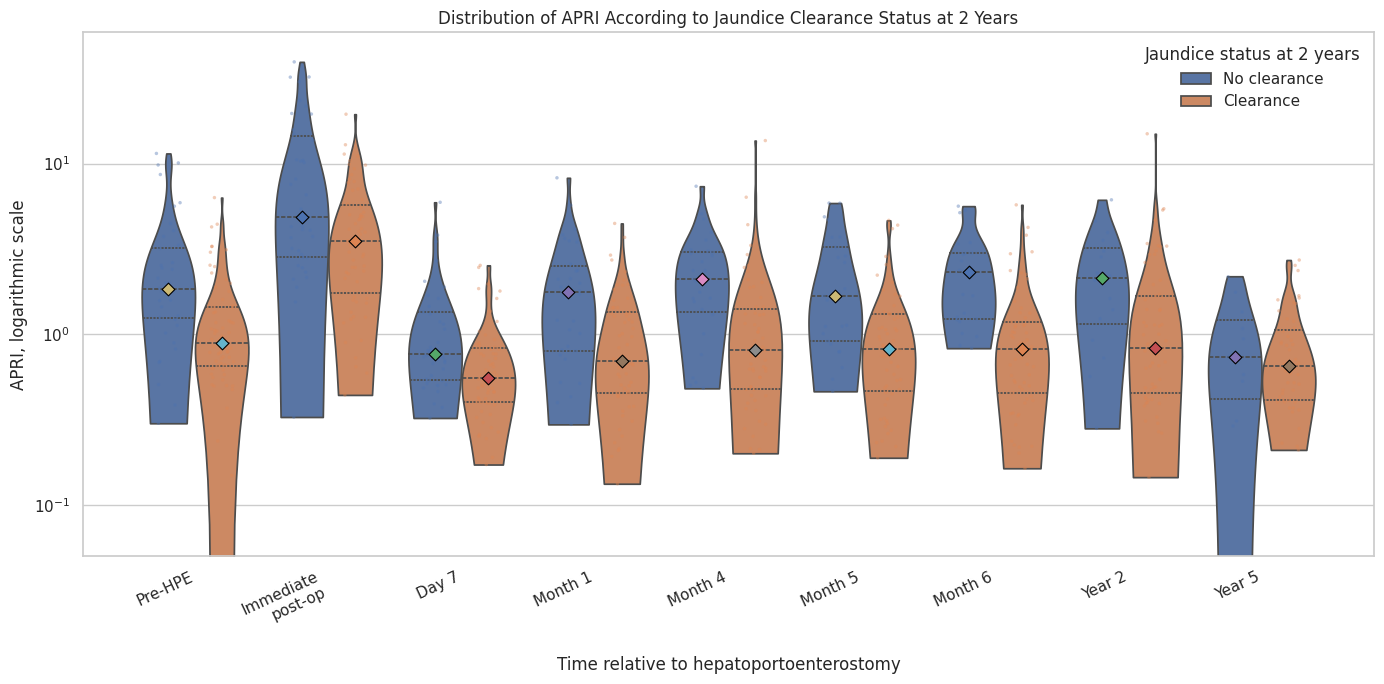

In [ ]:
sns.set_theme(style="whitegrid")

long_df["log1p_APRI"] = np.log1p(long_df["APRI"])

fig, ax = plt.subplots(figsize=(14, 7))

sns.violinplot(
    data=long_df,
    x="Time",
    y="APRI",
    hue="Jaundice clearance",
    order=time_order,
    hue_order=["No clearance", "Clearance"],
    dodge=True,
    inner="quartile",
    cut=0,
    scale="width",
    ax=ax
)

ax.set_ylabel("log(1 + APRI)")

# Overlay individual observations
sns.stripplot(
    data=long_df,
    x="Time",
    y="APRI",
    hue="Jaundice clearance",
    order=time_order,
    hue_order=["No clearance", "Clearance"],
    dodge=True,
    jitter=0.18,
    size=2.5,
    alpha=0.40,
    ax=ax
)

# Calculate medians
median_df = (
    long_df
    .groupby(
        ["Time", "Jaundice clearance"],
        observed=True
    )["APRI"]
    .median()
    .reset_index()
)

# Horizontal positions of the two groups within each time point
offsets = {
    "No clearance": -0.20,
    "Clearance": 0.20
}

# Add median diamonds
for time_index, time_point in enumerate(time_order):

    for group in ["No clearance", "Clearance"]:

        median_value = median_df.loc[
            (median_df["Time"] == time_point) &
            (median_df["Jaundice clearance"] == group),
            "APRI"
        ]

        if not median_value.empty:
            ax.scatter(
                time_index + offsets[group],
                median_value.iloc[0],
                marker="D",
                s=42,
                edgecolor="black",
                linewidth=0.8,
                zorder=10
            )

# Remove duplicate legend entries created by violinplot and stripplot
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    title="Jaundice status at 2 years",
    frameon=False,
    loc="upper right"
)

ax.set_xlabel(
    "Time relative to hepatoportoenterostomy",
    labelpad=16
)

ax.set_yscale("log")
ax.set_ylim(0.05, None)
ax.set_ylabel("APRI, logarithmic scale")

ax.set_title(
    "Distribution of APRI According to Jaundice Clearance Status at 2 Years"
)

ax.tick_params(
    axis="x",
    labelrotation=25
)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.grid(axis="x", visible=False)

fig.subplots_adjust(bottom=0.24)
fig.tight_layout()

fig.savefig(
    "APRI_violin_by_2year_jaundice_clearance.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "APRI_violin_by_2year_jaundice_clearance.pdf",
    bbox_inches="tight"
)

plt.show()